## 1.1 Data Loading

In [ ]:

from google.colab import drive
drive.mount('/content/drive')

import os

DRIVE_DATA = '/content/drive/MyDrive/kkbox_data'
os.makedirs(DRIVE_DATA, exist_ok=True)
os.makedirs(f'{DRIVE_DATA}/results', exist_ok=True)
os.makedirs(f'{DRIVE_DATA}/models',  exist_ok=True)

print(" Drive mounted")


Mounted at /content/drive
 Drive mounted


# 1.2 Restore Kaggle credentials from Drive



kaggle.json was saved to Drive during first-time setup.

In [ ]:
import shutil

cred = f'{DRIVE_DATA}/kaggle.json'
os.makedirs('/root/.kaggle', exist_ok=True)

if os.path.exists(cred):
    shutil.copy(cred, '/root/.kaggle/kaggle.json')
    os.chmod('/root/.kaggle/kaggle.json', 0o600)
    print("Kaggle credentials restored")
else:
    print("kaggle.json not found on Drive")

Kaggle credentials restored


## 1.3 Uploading kaggle.json




In [ ]:



from google.colab import files
files.upload()
shutil.copy('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 0o600)


Saving kaggle.json to kaggle.json


## 1.4 Installing Libraries




In [ ]:

!pip install kaggle lightgbm xgboost shap imbalanced-learn optuna --upgrade --quiet
print("Libraries installed")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.2/110.2 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.8/217.8 kB 12.0 MB/s eta 0:00:00
Libraries installed


## 1.5 Importing Libraries

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gc, warnings, joblib
warnings.filterwarnings('ignore')

from sklearn.model_selection  import train_test_split
from sklearn.preprocessing    import StandardScaler
from sklearn.pipeline         import Pipeline
from sklearn.dummy            import DummyClassifier
from sklearn.linear_model     import LogisticRegression
from sklearn.ensemble         import RandomForestClassifier
from sklearn.metrics          import (roc_auc_score, log_loss, average_precision_score, f1_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay, classification_report)
import lightgbm as lgb
import xgboost  as xgb
import shap
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
from imblearn.over_sampling import SMOTE

print("All libraries imported")
print(f"pandas   {pd.__version__}")
print(f"lightgbm {lgb.__version__}")
print(f"xgboost  {xgb.__version__}")

All libraries imported
pandas   2.2.2
lightgbm 4.6.0
xgboost  3.2.0


##2. Utility Functions

Reduce mem is used to reduce memory and improve executing times

In [ ]:
def reduce_mem(df):
    for col in df.select_dtypes(include=[np.number]).columns:
        c_min, c_max = df[col].min(), df[col].max()
        if df[col].dtype.kind == 'i':
            for dtype in [np.int8, np.int16, np.int32]:
                if c_min > np.iinfo(dtype).min and c_max < np.iinfo(dtype).max:
                    df[col] = df[col].astype(dtype)
                    break
        else:
            if c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                df[col] = df[col].astype(np.float32)
    return df

In [ ]:
paths = {
    'train'       : f'{DRIVE_DATA}/train.csv',
    'members'     : f'{DRIVE_DATA}/members_v3.csv',
    'transactions': f'{DRIVE_DATA}/transactions.csv',
}

for name, path in paths.items():
    if os.path.exists(path):
        print(f"{name:<15} {os.path.getsize(path)/1e6:>8.1f} MB")
    else:
        print(f"{name:<15} not found")

train               46.7 MB
members            427.9 MB
transactions      1729.3 MB


Feature engineering on 21.5 million transaction rows takes several minutes every time. So after running it once, you save the result as a parquet file on Drive

In [ ]:
parquet_path = f'{DRIVE_DATA}/features.parquet'

if os.path.exists(parquet_path):
    df = pd.read_parquet(parquet_path)
    print(f" features.parquet loaded — {df.shape[0]:,} rows, churn rate: {df['is_churn'].mean():.2%}")
    print(" Skip to EDA")
else:
    print(" No parquet found")

 features.parquet loaded — 992,931 rows, churn rate: 6.39%
 Skip to EDA


## Loading train.csv

In [ ]:
train = reduce_mem(pd.read_csv(paths['train']))

print(f"Rows: {train.shape[0]:,}")
print(f"Churned : {train['is_churn'].mean():.2%}")
print(f"Renewed : {1-train['is_churn'].mean():.2%}")

Rows: 992,931
Churned : 6.39%
Renewed : 93.61%





## Loading members_v3.csv

In [ ]:
members = reduce_mem(pd.read_csv(paths['members'], parse_dates=['registration_init_time']))
print(members.isnull().sum()[members.isnull().sum() > 0])
print(members.shape)
print(members.columns)

gender    4429505
dtype: int64
(6769473, 6)
Index(['msno', 'city', 'bd', 'gender', 'registered_via',
       'registration_init_time'],
      dtype='object')






## Loading transactions.csv

In [ ]:
transactions = reduce_mem(pd.read_csv(
    paths['transactions'],
    parse_dates=['transaction_date', 'membership_expire_date']
))
print(transactions.shape)


(21547746, 9)


## Data Audit

In [ ]:
for name, tbl in [('TRAIN', train), ('MEMBERS', members), ('TRANSACTIONS', transactions)]:
    missing = tbl.isnull().sum()
    missing = missing[missing > 0]
    print(f"\n{name}")
    print(missing if len(missing) else "No missing values")


TRAIN
No missing values

MEMBERS
gender    4429505
dtype: int64

TRANSACTIONS
No missing values


# 3.1  Transaction feature engineering





In [ ]:
CUTOFF_DATE = pd.Timestamp('2017-01-31')

trans_feats = (
    transactions[transactions['transaction_date'] <= CUTOFF_DATE]
    .sort_values(['msno', 'transaction_date'])
    .groupby('msno')
    .agg(
        trans_count     = ('transaction_date',  'count'),
        auto_renew_rate = ('is_auto_renew',      'mean'),
        cancel_rate     = ('is_cancel',          'mean'),
        total_paid      = ('actual_amount_paid', 'sum'),
        avg_paid        = ('actual_amount_paid', 'mean'),
        last_paid       = ('actual_amount_paid', 'last'),
        avg_plan_days   = ('payment_plan_days',  'mean'),
        last_plan_days  = ('payment_plan_days',  'last'),
        first_trans     = ('transaction_date',   'first'),
        last_trans      = ('transaction_date',   'max'),
    )
    .reset_index()
)

trans_feats['tenure_days']  = (trans_feats['last_trans'] - trans_feats['first_trans']).dt.days
trans_feats['recency_days'] = (CUTOFF_DATE - trans_feats['last_trans']).dt.days
trans_feats.drop(columns=['first_trans', 'last_trans'], inplace=True)

## 3.2 Member feature engineering

In [ ]:
mf = members.copy()

mf['member_age']         = mf['bd'].clip(1, 100)
mf['member_age_missing'] = ((mf['bd'] <= 0) | (mf['bd'] > 100)).astype(np.int8)
mf['member_reg_days']    = (CUTOFF_DATE - mf['registration_init_time']).dt.days
mf['member_age_bin']     = pd.cut(mf['member_age'], bins=[0,20,30,40,50,60,100], labels=[0,1,2,3,4,5]).astype('float32')
mf['gender_enc']         = mf['gender'].map({'male': 1, 'female': 0}).fillna(-1).astype(np.int8)

member_feats = mf[['msno','city','member_age','member_age_missing',
                    'gender_enc','member_reg_days','member_age_bin','registered_via']]

## 3.3 Merging all the files

In [ ]:
df = train.merge(member_feats, on='msno', how='left').merge(trans_feats, on='msno', how='left')

print(f"Shape: {df.shape}")
print(f"Churn rate: {df['is_churn'].mean():.2%}")
print(df.isnull().sum()[df.isnull().sum() > 0])

Shape: (992931, 19)
Churn rate: 6.39%
city                  115770
member_age            115770
member_age_missing    115770
gender_enc            115770
member_reg_days       115770
member_age_bin        115770
registered_via        115770
trans_count             2097
auto_renew_rate         2097
cancel_rate             2097
total_paid              2097
avg_paid                2097
last_paid               2097
avg_plan_days           2097
last_plan_days          2097
tenure_days             2097
recency_days            2097
dtype: int64


## Using Parquet files to save memory

In [ ]:
df.to_parquet(f'{DRIVE_DATA}/features.parquet', index=False)

del trans_feats, member_feats, members, transactions, train
gc.collect()
print("Saved and memory freed")

Saved and memory freed


In [ ]:
print(df.columns.tolist())

['msno', 'is_churn', 'city', 'member_age', 'member_age_missing', 'gender_enc', 'member_reg_days', 'member_age_bin', 'registered_via', 'trans_count', 'auto_renew_rate', 'cancel_rate', 'total_paid', 'avg_paid', 'last_paid', 'avg_plan_days', 'last_plan_days', 'tenure_days', 'recency_days']


## Exploratory Data Analysis

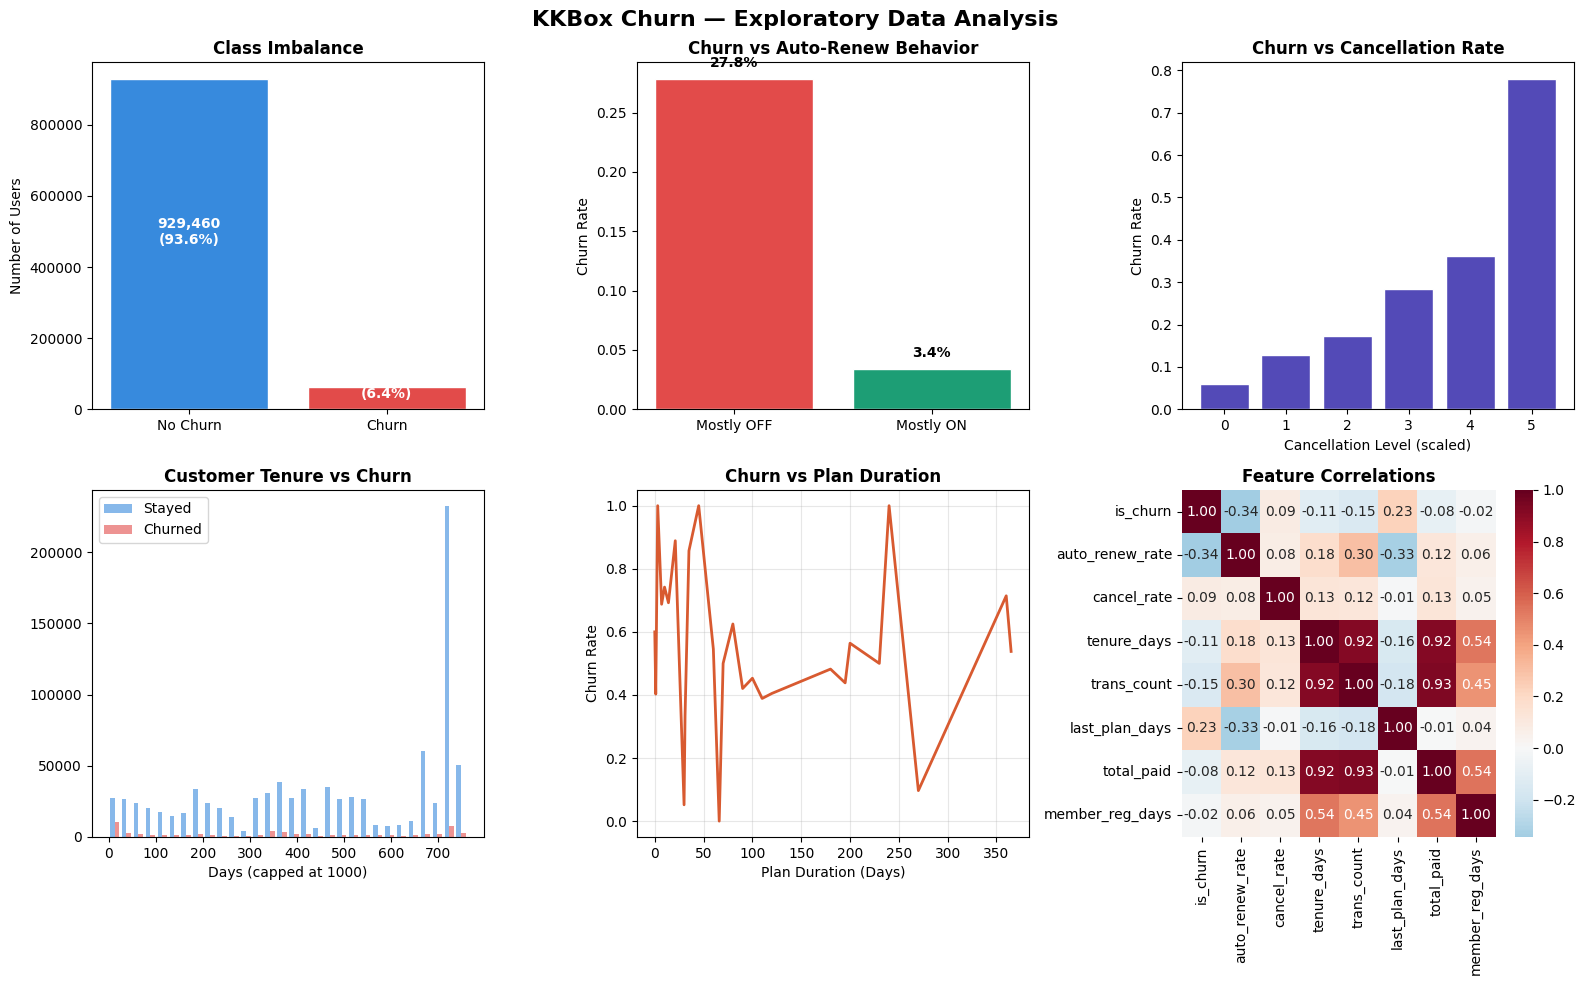

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('KKBox Churn — Exploratory Data Analysis',
             fontsize=16, fontweight='bold')

# ── Panel 1: Class imbalance ────────────────────────────────
counts = df['is_churn'].value_counts()
axes[0,0].bar(['No Churn', 'Churn'], counts.values,
               color=['#378ADD', '#E24B4A'], edgecolor='white')
axes[0,0].set_title('Class Imbalance', fontweight='bold')
axes[0,0].set_ylabel('Number of Users')

for i, v in enumerate(counts.values):
    axes[0,0].text(i, v*0.5,
                   f'{v:,}\n({v/len(df):.1%})',
                   ha='center', color='white',
                   fontweight='bold')

# ── Panel 2: Auto-renewal behavior (rate-based) ─────────────
df['auto_renew_flag'] = (df['auto_renew_rate'] > 0.5).astype(int)
ar = df.groupby('auto_renew_flag')['is_churn'].mean()

axes[0,1].bar(['Mostly OFF', 'Mostly ON'], ar.values,
               color=['#E24B4A', '#1D9E75'], edgecolor='white')
axes[0,1].set_title('Churn vs Auto-Renew Behavior', fontweight='bold')
axes[0,1].set_ylabel('Churn Rate')

for i, v in enumerate(ar.values):
    axes[0,1].text(i, v + 0.01, f'{v:.1%}',
                   ha='center', fontweight='bold')

# ── Panel 3: Cancellation behavior ─────────────────────────
df['cancel_bucket'] = (
    (df['cancel_rate'].fillna(0) * 10)
    .clip(0, 5)
    .astype(int)
)
cc = df.groupby('cancel_bucket')['is_churn'].mean()

axes[0,2].bar(cc.index.astype(str), cc.values,
               color='#534AB7', edgecolor='white')
axes[0,2].set_title('Churn vs Cancellation Rate', fontweight='bold')
axes[0,2].set_xlabel('Cancellation Level (scaled)')
axes[0,2].set_ylabel('Churn Rate')

# ── Panel 4: Tenure ─────────────────────────────────────────
axes[1,0].hist(
    [df[df['is_churn']==0]['tenure_days'].dropna().clip(0,1000),
     df[df['is_churn']==1]['tenure_days'].dropna().clip(0,1000)],
    bins=30, alpha=0.6,
    label=['Stayed','Churned'],
    color=['#378ADD','#E24B4A']
)
axes[1,0].set_title('Customer Tenure vs Churn', fontweight='bold')
axes[1,0].set_xlabel('Days (capped at 1000)')
axes[1,0].legend()

# ── Panel 5: Plan duration ──────────────────────────────────
plan_churn = df.groupby(
    df['last_plan_days'].clip(upper=365))['is_churn'].mean()

axes[1,1].plot(plan_churn.index, plan_churn.values,
               color='#D85A30', linewidth=2)
axes[1,1].set_title('Churn vs Plan Duration', fontweight='bold')
axes[1,1].set_xlabel('Plan Duration (Days)')
axes[1,1].set_ylabel('Churn Rate')
axes[1,1].grid(True, alpha=0.3)

# ── Panel 6: Correlation ────────────────────────────────────
top_cols = ['is_churn','auto_renew_rate','cancel_rate',
            'tenure_days','trans_count','last_plan_days',
            'total_paid','member_reg_days']

sns.heatmap(df[top_cols].corr(),
            ax=axes[1,2],
            annot=True,
            fmt='.2f',
            cmap='RdBu_r',
            center=0)

axes[1,2].set_title('Feature Correlations', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{DRIVE_DATA}/results/eda_overview.png',
            dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
df['auto_renew_flag'] = (df['auto_renew_rate'].fillna(0) > 0.5).astype(int)

ar_off = df[df['auto_renew_flag']==0]['is_churn'].mean()
ar_on  = df[df['auto_renew_flag']==1]['is_churn'].mean()
med_churn  = df[df['is_churn']==1]['tenure_days'].median()
med_stayed = df[df['is_churn']==0]['tenure_days'].median()

print(f"Auto-renew OFF: {ar_off:.1%} churn  |  ON: {ar_on:.1%} churn  |  Ratio: {ar_off/ar_on:.1f}x")
print(f"Churner tenure: {med_churn:.0f} days  |  Stayer tenure: {med_stayed:.0f} days")
print(f"Churn rate: {df['is_churn'].mean():.1%}")

Auto-renew OFF: 27.8% churn  |  ON: 3.4% churn  |  Ratio: 8.2x
Churner tenure: 361 days  |  Stayer tenure: 488 days
Churn rate: 6.4%


Loading Features


In [ ]:
FEATURES = [
    'city', 'member_age', 'member_age_missing',
    'gender_enc', 'member_reg_days', 'member_age_bin', 'registered_via',
    'trans_count', 'auto_renew_rate', 'cancel_rate',
    'total_paid', 'avg_paid', 'last_paid',
    'avg_plan_days', 'last_plan_days',
    'tenure_days', 'recency_days'
]

X = df[FEATURES].copy()
y = df['is_churn'].copy()

## Test Validation Split

In [ ]:
X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.176, random_state=42, stratify=y_trainval)

print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")

Train: (695448, 17) | Val: (148543, 17) | Test: (148940, 17)


In [ ]:
num_cols = X_train.select_dtypes(include=[np.number]).columns
train_medians = X_train[num_cols].median()

X_train[num_cols] = X_train[num_cols].fillna(train_medians)
X_val[num_cols]   = X_val[num_cols].fillna(train_medians)
X_test[num_cols]  = X_test[num_cols].fillna(train_medians)

In [ ]:
assert X_train.isnull().sum().sum() == 0
assert X_val.isnull().sum().sum()   == 0
assert X_test.isnull().sum().sum()  == 0
assert list(X_train.columns) == list(X_val.columns) == list(X_test.columns)

print(f"Train: {X_train.shape} churn={y_train.mean():.2%}")
print(f"Val  : {X_val.shape}   churn={y_val.mean():.2%}")
print(f"Test : {X_test.shape}  churn={y_test.mean():.2%}")

Train: (695448, 17) churn=6.39%
Val  : (148543, 17)   churn=6.39%
Test : (148940, 17)  churn=6.39%


## Scale POS Weight

In [ ]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.1f}")

scale_pos_weight: 14.6


In [ ]:
all_results = {}

def evaluate_model(name, model, X_eval, y_eval, store=True):
    proba   = model.predict_proba(X_eval)[:, 1]
    metrics = {
        'ROC-AUC' : round(roc_auc_score(y_eval, proba), 4),
        'PR-AUC'  : round(average_precision_score(y_eval, proba), 4),
        'Log Loss': round(log_loss(y_eval, proba, labels=[0,1]), 4),
    }
    print(f"  ROC-AUC: {metrics['ROC-AUC']}  |  Log Loss: {metrics['Log Loss']}  |  PR-AUC: {metrics['PR-AUC']}")
    if store:
        all_results[name] = metrics
    return metrics

## Dummy Classifier


In [ ]:
dummy = DummyClassifier(strategy='stratified', random_state=42)
dummy.fit(X_train, y_train)
evaluate_model('1. Dummy', dummy, X_val, y_val)
joblib.dump(dummy, f'{DRIVE_DATA}/models/dummy.pkl')

  ROC-AUC: 0.4981  |  Log Loss: 4.299  |  PR-AUC: 0.0637


['/content/drive/MyDrive/kkbox_data/models/dummy.pkl']

## Logistic Regression

In [ ]:
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(C=0.1, class_weight='balanced', max_iter=1000, random_state=42))
])

lr_pipe.fit(X_train, y_train)
evaluate_model('2. Logistic Regression', lr_pipe, X_val, y_val)
joblib.dump(lr_pipe, f'{DRIVE_DATA}/models/lr.pkl')

  ROC-AUC: 0.8036  |  Log Loss: 0.5026  |  PR-AUC: 0.3401


['/content/drive/MyDrive/kkbox_data/models/lr.pkl']

In [ ]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(lr_pipe, X_val, y_val, n_repeats=5, random_state=42)
pd.Series(perm.importances_mean, index=X_train.columns).sort_values(ascending=False).head(10)

,0
auto_renew_rate,0.045905
recency_days,0.018785
last_paid,0.004571
avg_plan_days,0.004041
cancel_rate,0.003521
avg_paid,0.001442
total_paid,0.001185
gender_enc,0.001116
member_age_bin,0.000339
city,0.000226


## Random Forest

In [ ]:
rf = RandomForestClassifier(
    n_estimators=300, max_depth=12, min_samples_leaf=50,
    class_weight='balanced_subsample', random_state=42, n_jobs=-1
)

rf.fit(X_train, y_train)
evaluate_model('3. Random Forest', rf, X_val, y_val)
joblib.dump(rf, f'{DRIVE_DATA}/models/rf.pkl')

  ROC-AUC: 0.8751  |  Log Loss: 0.4131  |  PR-AUC: 0.4595


['/content/drive/MyDrive/kkbox_data/models/rf.pkl']

In [ ]:
print("Train AUC:", roc_auc_score(y_train, rf.predict_proba(X_train)[:,1]))
print("Val AUC  :", roc_auc_score(y_val, rf.predict_proba(X_val)[:,1]))

Train AUC: 0.8857465829302318
Val AUC  : 0.8751469777833888


## XGBoost

In [ ]:
xgb_model = xgb.XGBClassifier(
    n_estimators=1000, learning_rate=0.05, max_depth=6,
    min_child_weight=5, subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight, eval_metric='auc',
    random_state=42, tree_method='hist', n_jobs=-1, verbosity=0
)

xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=100)
evaluate_model('4. XGBoost', xgb_model, X_val, y_val)
joblib.dump(xgb_model, f'{DRIVE_DATA}/models/xgb.pkl')

[0]	validation_0-auc:0.83597
[100]	validation_0-auc:0.87326
[200]	validation_0-auc:0.87746
[300]	validation_0-auc:0.87859
[400]	validation_0-auc:0.87899
[500]	validation_0-auc:0.87905
[600]	validation_0-auc:0.87904
[700]	validation_0-auc:0.87870
[800]	validation_0-auc:0.87846
[900]	validation_0-auc:0.87825
[999]	validation_0-auc:0.87792
  ROC-AUC: 0.8779  |  Log Loss: 0.3891  |  PR-AUC: 0.4852


['/content/drive/MyDrive/kkbox_data/models/xgb.pkl']

In [ ]:
def objective(trial):
    params = {
        'n_estimators'     : trial.suggest_int  ('n_estimators',      300,  1500),
        'learning_rate'    : trial.suggest_float ('learning_rate',     0.01, 0.1, log=True),
        'max_depth'        : trial.suggest_int   ('max_depth',         4,    10),
        'num_leaves'       : trial.suggest_int   ('num_leaves',        31,   200),
        'min_child_samples': trial.suggest_int   ('min_child_samples', 20,   200),
        'subsample'        : trial.suggest_float ('subsample',         0.6,  1.0),
        'colsample_bytree' : trial.suggest_float ('colsample_bytree',  0.6,  1.0),
        'reg_alpha'        : trial.suggest_float ('reg_alpha',         1e-4, 10.0, log=True),
        'reg_lambda'       : trial.suggest_float ('reg_lambda',        1e-4, 10.0, log=True),
        'scale_pos_weight' : scale_pos_weight,
        'random_state'     : 42,
        'n_jobs'           : -1,
        'verbosity'        : -1,
    }
    model = lgb.LGBMClassifier(**params)
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)],
              callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])
    return roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])

In [ ]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)

In [ ]:
best_params = {
    **study.best_params,
    'scale_pos_weight': scale_pos_weight,
    'random_state': 42,
    'n_jobs': -1,
    'verbosity': -1
}

## LightGBM

In [ ]:
lgbm_final = lgb.LGBMClassifier(**best_params)

lgbm_final.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[
        lgb.early_stopping(50, verbose=False),
        lgb.log_evaluation(100)
    ]
)

LGBMClassifier(colsample_bytree=0.7929295481071531,
               learning_rate=0.010411701985694084, max_depth=10,
               min_child_samples=182, n_estimators=725, n_jobs=-1,
               num_leaves=120, random_state=42, reg_alpha=0.0017407294501802402,
               reg_lambda=0.00010027924958769388,
               scale_pos_weight=np.float64(14.643864582161736),
               subsample=0.7664352512522293, verbosity=-1)

In [ ]:
test_proba = lgbm_final.predict_proba(X_test)[:, 1]

print(f"ROC-AUC  : {roc_auc_score(y_test, test_proba):.4f}")
print(f"PR-AUC   : {average_precision_score(y_test, test_proba):.4f}")
print(f"Log Loss : {log_loss(y_test, test_proba, labels=[0,1]):.4f}")

ROC-AUC  : 0.8797
PR-AUC   : 0.4449
Log Loss : 0.2154


In [ ]:
print("Train AUC:", roc_auc_score(y_train, lgbm_final.predict_proba(X_train)[:,1]))
print("Val AUC  :", roc_auc_score(y_val,   lgbm_final.predict_proba(X_val)[:,1]))

Train AUC: 0.8808879504176577
Val AUC  : 0.8754726255743601


## All Results

In [ ]:
evaluate_model('1. Dummy',                dummy,       X_val, y_val)
evaluate_model('2. Logistic Regression',  lr_pipe,     X_val, y_val)
evaluate_model('3. Random Forest',        rf,          X_val, y_val)
evaluate_model('4. XGBoost',              xgb_model,   X_val, y_val)
evaluate_model('5. LightGBM (Optuna)',    lgbm_final,  X_val, y_val)

  ROC-AUC: 0.4981  |  Log Loss: 4.299  |  PR-AUC: 0.0637
  ROC-AUC: 0.8036  |  Log Loss: 0.5026  |  PR-AUC: 0.3401
  ROC-AUC: 0.8751  |  Log Loss: 0.4131  |  PR-AUC: 0.4595
  ROC-AUC: 0.8779  |  Log Loss: 0.3891  |  PR-AUC: 0.4852
  ROC-AUC: 0.8755  |  Log Loss: 0.2158  |  PR-AUC: 0.4471


{'ROC-AUC': np.float64(0.8755),
 'PR-AUC': np.float64(0.4471),
 'Log Loss': 0.2158}

In [ ]:
results_df = pd.DataFrame(all_results).T.sort_values('ROC-AUC', ascending=False)
print(results_df.round(4))
results_df.to_csv(f'{DRIVE_DATA}/results/model_comparison.csv')

                        ROC-AUC  PR-AUC  Log Loss
4. XGBoost               0.8779  0.4852    0.3891
5. LightGBM (Optuna)     0.8755  0.4471    0.2158
3. Random Forest         0.8751  0.4595    0.4131
2. Logistic Regression   0.8036  0.3401    0.5026
1. Dummy                 0.4981  0.0637    4.2990


## Shap Features

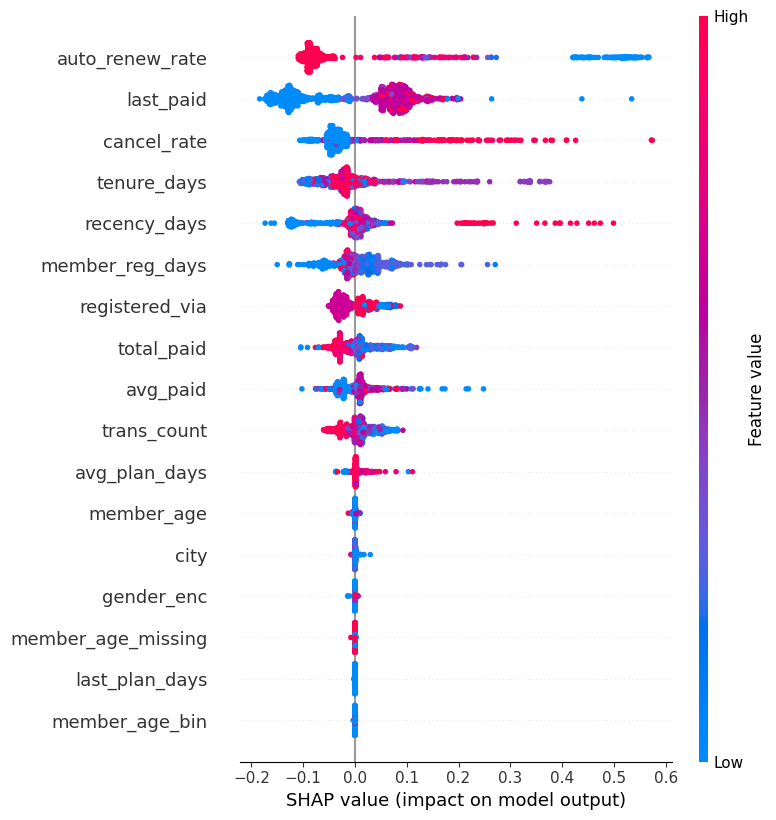

auto_renew_rate    0.126298
last_paid          0.097172
cancel_rate        0.056499
tenure_days        0.048200
recency_days       0.037143
member_reg_days    0.032667
registered_via     0.027940
total_paid         0.026930
avg_paid           0.022724
trans_count        0.021676
dtype: float64


In [ ]:
import shap

explainer = shap.TreeExplainer(lgbm_final)
shap_values = explainer.shap_values(X_test.iloc[:1000])

# Handle LightGBM returning a list (index 1 = churn class)
sv = shap_values[1] if isinstance(shap_values, list) else shap_values

# Summary plot
shap.summary_plot(sv, X_test.iloc[:1000])

# Ranked feature importance table
mean_abs_shap = pd.Series(
    np.abs(sv).mean(axis=0),
    index=X_test.columns
).sort_values(ascending=False)

print(mean_abs_shap.head(10))

## ROC Curve

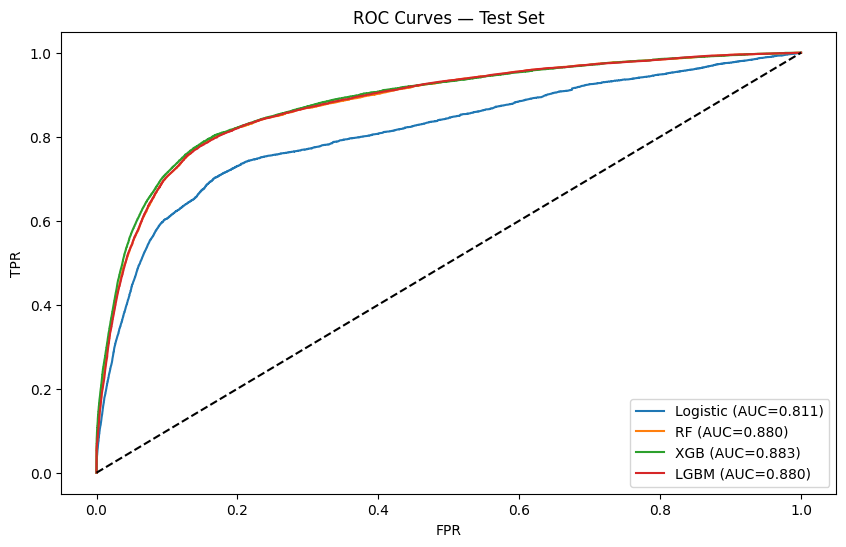

In [ ]:
models_dict = {'Logistic': lr_pipe, 'RF': rf, 'XGB': xgb_model, 'LGBM': lgbm_final}

plt.figure(figsize=(10, 6))
for name, model in models_dict.items():
    p = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, p)
    plt.plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(y_test, p):.3f})')

plt.plot([0,1], [0,1], 'k--')
plt.title('ROC Curves — Test Set')
plt.xlabel('FPR'); plt.ylabel('TPR')
plt.legend()
plt.show()

## Confusion Matrix

Optimal threshold: 0.18


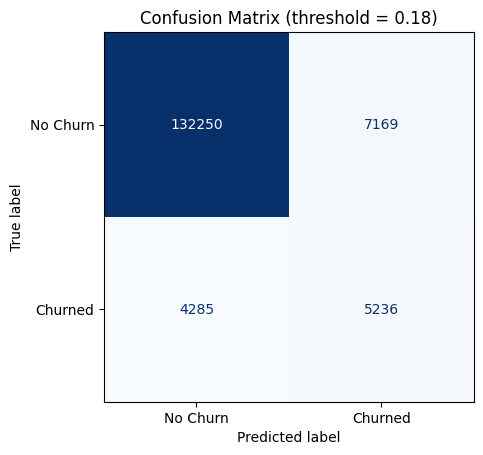

              precision    recall  f1-score   support

    No Churn       0.97      0.95      0.96    139419
     Churned       0.42      0.55      0.48      9521

    accuracy                           0.92    148940
   macro avg       0.70      0.75      0.72    148940
weighted avg       0.93      0.92      0.93    148940



In [ ]:
thresholds = np.linspace(0.05, 0.95, 100)
best_t = thresholds[np.argmax([f1_score(y_test, test_proba >= t) for t in thresholds])]
y_pred = (test_proba >= best_t).astype(int)

print(f"Optimal threshold: {best_t:.2f}")

disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels=['No Churn', 'Churned'])
disp.plot(cmap='Blues', colorbar=False)
plt.title(f'Confusion Matrix (threshold = {best_t:.2f})')
plt.show()

print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churned']))